### Analysis Overview

- Compares **cell type contributions** between **AD** and **NCI** cohorts for each **deconvolution tool**.  
- Uses **Mann–Whitney U tests** to assess cohort differences within each tool.  
- Produces **boxplots with jittered points** showing AD and NCI distributions side by side.  
- Adds **significance brackets and p-value stars** above each pair (based on raw p-values).  
- Saves both **plots (PNG/PDF)** and **statistical summaries (CSV)** for each tissue.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------- Helper function ----------
def pval_to_star(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------- Load data ----------
files = {
    "NCI": "TSP-BDa_Outer_300_1500_10-Toden-NCI/merged_normalised_results_Toden_NCI.txt",
    "AD":  "TSP-BDa_Outer_300_1500_10-Toden-AD/merged_normalised_results_Toden_AD.txt"
}

dfs = []
for cohort, path in files.items():
    df = pd.read_csv(path, sep="\t")
    df["Cohort"] = cohort
    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)
print(f"Loaded {merged.shape[0]} samples across {merged['Method'].nunique()} methods.")

# ---------- Reshape ----------
long_df = merged.melt(
    id_vars=["Sample", "Method", "Cohort"],
    var_name="CellType",
    value_name="Contribution"
)
long_df["Contribution"] = pd.to_numeric(long_df["Contribution"], errors="coerce")
long_df = long_df.dropna(subset=["Contribution"])

# ---------- Statistical testing ----------
results = []
for (method, celltype), df_sub in long_df.groupby(["Method", "CellType"]):
    group_data = {c: vals["Contribution"].values for c, vals in df_sub.groupby("Cohort")}
    if "NCI" in group_data and "AD" in group_data:
        nci_vals = group_data["NCI"]
        ad_vals  = group_data["AD"]

        if len(nci_vals) > 0 and len(ad_vals) > 0:
            try:
                # Compute medians and Mann–Whitney test
                median_nci = np.median(nci_vals)
                median_ad  = np.median(ad_vals)
                delta    = median_ad - median_nci
                stat, pval = mannwhitneyu(nci_vals, ad_vals, alternative="two-sided")

                results.append({
                    "Method": method,
                    "CellType": celltype,
                    "pval": pval,
                    "Significant": pval < 0.05,
                    "Stars": pval_to_star(pval),
                    "median_AD": median_ad,
                    "median_NCI": median_nci,
                    "Delta_AD_minus_NCI": delta,
                    "Direction": "AD > NCI" if delta > 0 else "NCI > AD"
                })
            except Exception as e:
                print(f"Skipping {method} - {celltype}: {e}")

# ---------- Collect results ----------
results_df = pd.DataFrame(results)

# Apply BH correction
# ---------- Apply BH correction (WITHIN TOOL / Method) ----------
results_df["pval_BH"] = np.nan

for method, idx in results_df.groupby("Method").groups.items():
    valid = results_df.loc[idx, "pval"].dropna()
    if len(valid) == 0:
        continue
    _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
    results_df.loc[valid.index, "pval_BH"] = p_corr

results_df["Significant_BH"] = results_df["pval_BH"] < 0.05
results_df["Stars_BH"] = results_df["pval_BH"].apply(pval_to_star)

# Optional: print significant ones after correction
sig_bh = results_df[results_df["Significant_BH"]].sort_values("pval_BH")
print("\n=== Statistically Significant Differences (FDR < 0.05, BH-corrected) ===")
for _, row in sig_bh.iterrows():
    arrow = "↑" if row["Delta_AD_minus_NCI"] > 0 else "↓"
    print(f"{row['Method']:12s} | {row['CellType'][:40]:40s} | "
          f"FDR = {row['pval_BH']:.3e} {row['Stars_BH']:4s} | "
          f"{row['Direction']:9s} ({arrow}) | Δ = {row['Delta_AD_minus_NCI']:.3f}")

# ---------- Print significant results ----------
print("\n=== Statistically Significant Differences (p < 0.05, uncorrected) ===")
sig_df = results_df[results_df["Significant"]].sort_values("pval")
if sig_df.empty:
    print("No significant differences found between AD and NCI cohorts.")
else:
    for _, row in sig_df.iterrows():
        arrow = "↑" if row["Delta_AD_minus_NCI"] > 0 else "↓"
        print(f"{row['Method']:12s} | {row['CellType'][:40]:40s} | "
              f"p = {row['pval']:.3e} {row['Stars']:4s} | "
              f"{row['Direction']:9s} ({arrow}) | Δ = {row['Delta_AD_minus_NCI']:.3f}")

# ---------- Save all results ----------
results_df.to_csv("AllCellTypes_AD_vs_NCI_BH_WithinTool.csv", index=False)
print("\nFull statistical results saved to: AllCellTypes_AD_vs_NCI_BH_WithinTool.csv")

# ---------- Save only significant with higher ALT ----------
sig_high = sig_df[sig_df["Direction"] == "AD > NCI"]
sig_high.to_csv("Significant_AD_higher_CellTypes_BH_WithinTool.csv", index=False)
print("Significant cell types with higher median in High ALT group saved to: Significant_AD_higher_CellTypes_BH_WithinTool.csv")

Loaded 1694 samples across 7 methods.

=== Statistically Significant Differences (FDR < 0.05, BH-corrected) ===
BayesPrism   | taste receptor cell                      | FDR = 1.131e-14 **** | NCI > AD  (↓) | Δ = -0.601
MuSiC        | common myeloid progenitor/erythroid prog | FDR = 1.642e-14 **** | NCI > AD  (↓) | Δ = -2.544
ReDeconv     | neuro-medullary thymic epithelial cell   | FDR = 2.035e-14 **** | NCI > AD  (↓) | Δ = -0.975
BayesPrism   | hepatocyte                               | FDR = 5.536e-14 **** | NCI > AD  (↓) | Δ = -0.114
BayesPrism   | pancreatic ductal cell                   | FDR = 6.274e-14 **** | NCI > AD  (↓) | Δ = -0.001
BayesPrism   | myo-medullary thymic epithelial cell     | FDR = 1.738e-13 **** | NCI > AD  (↓) | Δ = -0.017
nuSVR        | myeloid dendritic cell                   | FDR = 3.478e-13 **** | AD > NCI  (↑) | Δ = 2.577
MuSiC        | pancreatic acinar cell                   | FDR = 1.567e-12 **** | NCI > AD  (↓) | Δ = -0.001
nuSVR        | neutrophil

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, patches
import matplotlib as mpl
# ---------- Helper: figure size driven by heatmap content ----------
def fig_for_heatmap(data, cell_in=0.28,
                    left_in=1.2, right_in=0.9, bottom_in=1.0, top_in=0.3):
    """
    data: 2D matrix (rows x cols) being plotted
    cell_in: desired square size per cell in inches
    margins_*_in: fixed margins reserved for labels/colorbar
    """
    nrows, ncols = data.shape

    fig_w = ncols * cell_in + left_in + right_in
    fig_h = nrows * cell_in + top_in + bottom_in

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    fig.subplots_adjust(
        left=left_in / fig_w,
        right=1 - right_in / fig_w,
        bottom=bottom_in / fig_h,
        top=1 - top_in / fig_h
    )
    return fig, ax

/tmp/ipykernel_3001919/3387778519.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdBu_r").copy()


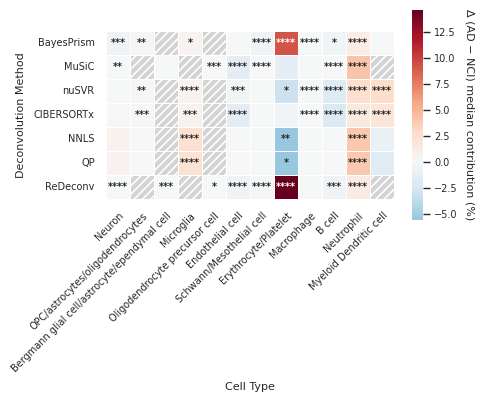

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, patches
import matplotlib as mpl

sns.set_theme(style="white", context="paper")  # context scales fonts nicely

mpl.rcParams.update({
    # Fonts (Illustrator-friendly)
    "font.family": "DejaVu Sans",
    "font.sans-serif": ["DejaVu Sans"],

    # Keep text as text in vector outputs
    "svg.fonttype": "none",     # <-- key for editable text in SVG
    "pdf.fonttype": 42,         # TrueType fonts embedded in PDF (also editable)
    "ps.fonttype": 42,

    # Sizes (tweak if needed)
    "font.size": 9,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 13,

    # Lines
    "axes.linewidth": 0.8,
    "hatch.linewidth": 1.2,

    # Save
    "savefig.bbox": "tight",
    "savefig.transparent": True,  # handy for Illustrator layouts
})

# ---------- Load results ----------
results_df = pd.read_csv("AllCellTypes_AD_vs_NCI_BH_WithinTool.csv")

# ---------- Filter to relevant cell types ----------
celltype_map = {
    "neuron": "Neuron",
    "neurons": "Neuron",
    "OPC/astrocytes/oligodendrocytes": "OPC/astrocytes/oligodendrocytes",
    "Bergmann glial cell/astrocyte/ependymal cell": "Bergmann glial cell/astrocyte/ependymal cell",
    "microglia": "Microglia",
    "oligodendrocyte precursor cell": "Oligodendrocyte precursor cell",
    "endothelial cell/endothelial cell of arteriole/endothelial cell of lymphatic vessel/endothelial cell of venule/vein endothelial cell": "Endothelial cell",
    "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell": "Endothelial cell",
    "schwann cell": "Schwann/Mesothelial cell",
    "mesothelial cell/schwann cell": "Schwann/Mesothelial cell",
    "erythrocyte/platelet": "Erythrocyte/Platelet",
    "macrophage": "Macrophage",
    "b cell": "B cell",
    "neutrophil": "Neutrophil",
    "myeloid dendritic cell": "Myeloid Dendritic cell"
}

results_df = results_df[results_df["CellType"].isin(celltype_map.keys())].copy()
results_df["CellTypeGroup"] = results_df["CellType"].map(celltype_map)

# ---------- Prepare heatmap data ----------
heatmap_data = results_df.pivot(index="CellTypeGroup", columns="Method", values="Delta_AD_minus_NCI")
annot_data   = results_df.pivot(index="CellTypeGroup", columns="Method", values="Stars_BH")
annot_data = annot_data.replace("ns", "")

# ---------- Order rows and columns ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
cell_order = [
    "Neuron",
    "OPC/astrocytes/oligodendrocytes",
    "Bergmann glial cell/astrocyte/ependymal cell",
    "Microglia",
    "Oligodendrocyte precursor cell",
    "Endothelial cell",
    "Schwann/Mesothelial cell",
    "Erythrocyte/Platelet",
    "Macrophage",
    "B cell",
    "Neutrophil",
    "Myeloid Dendritic cell"
]

heatmap_data = heatmap_data.reindex(cell_order)[tool_order]
annot_data   = annot_data.reindex(cell_order)[tool_order]
mask = heatmap_data.isna()

# ---------- Transpose for plotting ----------
heatmap_plot = heatmap_data.T
annot_plot   = annot_data.T
mask_plot    = mask.T

# ---------- Plot (content-driven size) ----------
cmap = plt.cm.get_cmap("RdBu_r").copy()
cmap.set_bad(color="lightgrey")

# Pick a fixed cell size for ALL plots (tune once)
cell_in = 0.30  # try 0.26–0.34 depending on how many panels you want on A4
fig, ax = fig_for_heatmap(heatmap_plot, cell_in=cell_in,
                          left_in=1.1, right_in=0.9, bottom_in=1.0, top_in=0.3)

ax = sns.heatmap(
    heatmap_plot,
    annot=annot_plot,
    fmt="",
    cmap=cmap,
    center=0,
    linewidths=0.7,
    linecolor="white",
    mask=mask_plot,
    square=True,  # keeps cells square within the axes
    annot_kws={"fontsize": 9, "fontweight": "bold"},
    ax=ax
)

# ---- Force annotation (star) fontsize to 7 pt ----
star_set = {"*", "**", "***", "****"}
for t in ax.texts:
    if t.get_text() in star_set:
        t.set_fontsize(7)
        t.set_fontweight("bold")
        t.set_ha("center")
        t.set_va("center")

# ---------- Add hatched overlay for missing cells ----------
for y in range(heatmap_plot.shape[0]):      # methods
    for x in range(heatmap_plot.shape[1]):  # cell types
        if mask_plot.iloc[y, x]:
            ax.add_patch(
                patches.Rectangle((x, y), 1, 1,
                                  facecolor="none",
                                  edgecolor="white",
                                  hatch="////",
                                  linewidth=0.0)
            )

# ---------- Labels and formatting ----------
ax.set_xlabel("Cell Type", fontsize=8, labelpad=6)
ax.set_ylabel("Deconvolution Method", fontsize=8, labelpad=6)

ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# ---- Colorbar formatting ----
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label("Δ (AD − NCI) median contribution (%)",
               fontsize=8, rotation=270, labelpad=12)

sns.despine(left=True, bottom=True)

fig.savefig("Heatmap_AD_vs_NCI_SelectedCellTypes_BH_corrected_Transposed_BH_WithinTool.svg",
            format="svg", bbox_inches="tight")
plt.show()
plt.close(fig)

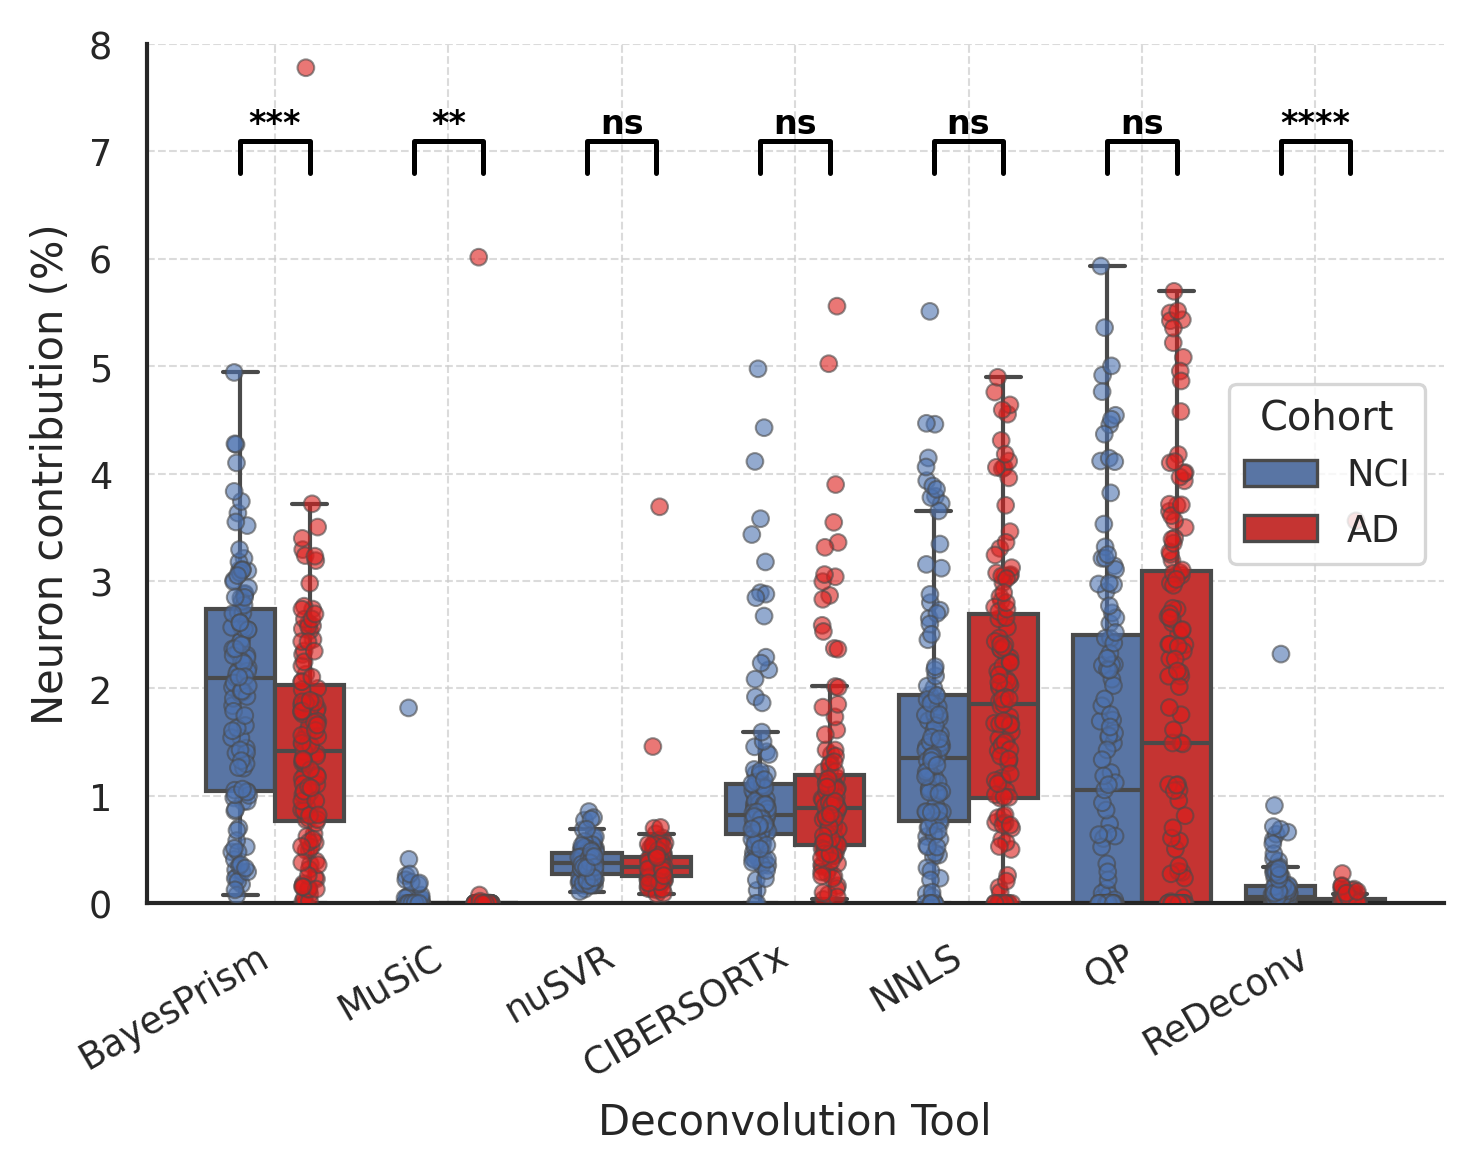

Saved: AD_vs_NCI_Neuron_boxstrip_BHWithinTool.svg


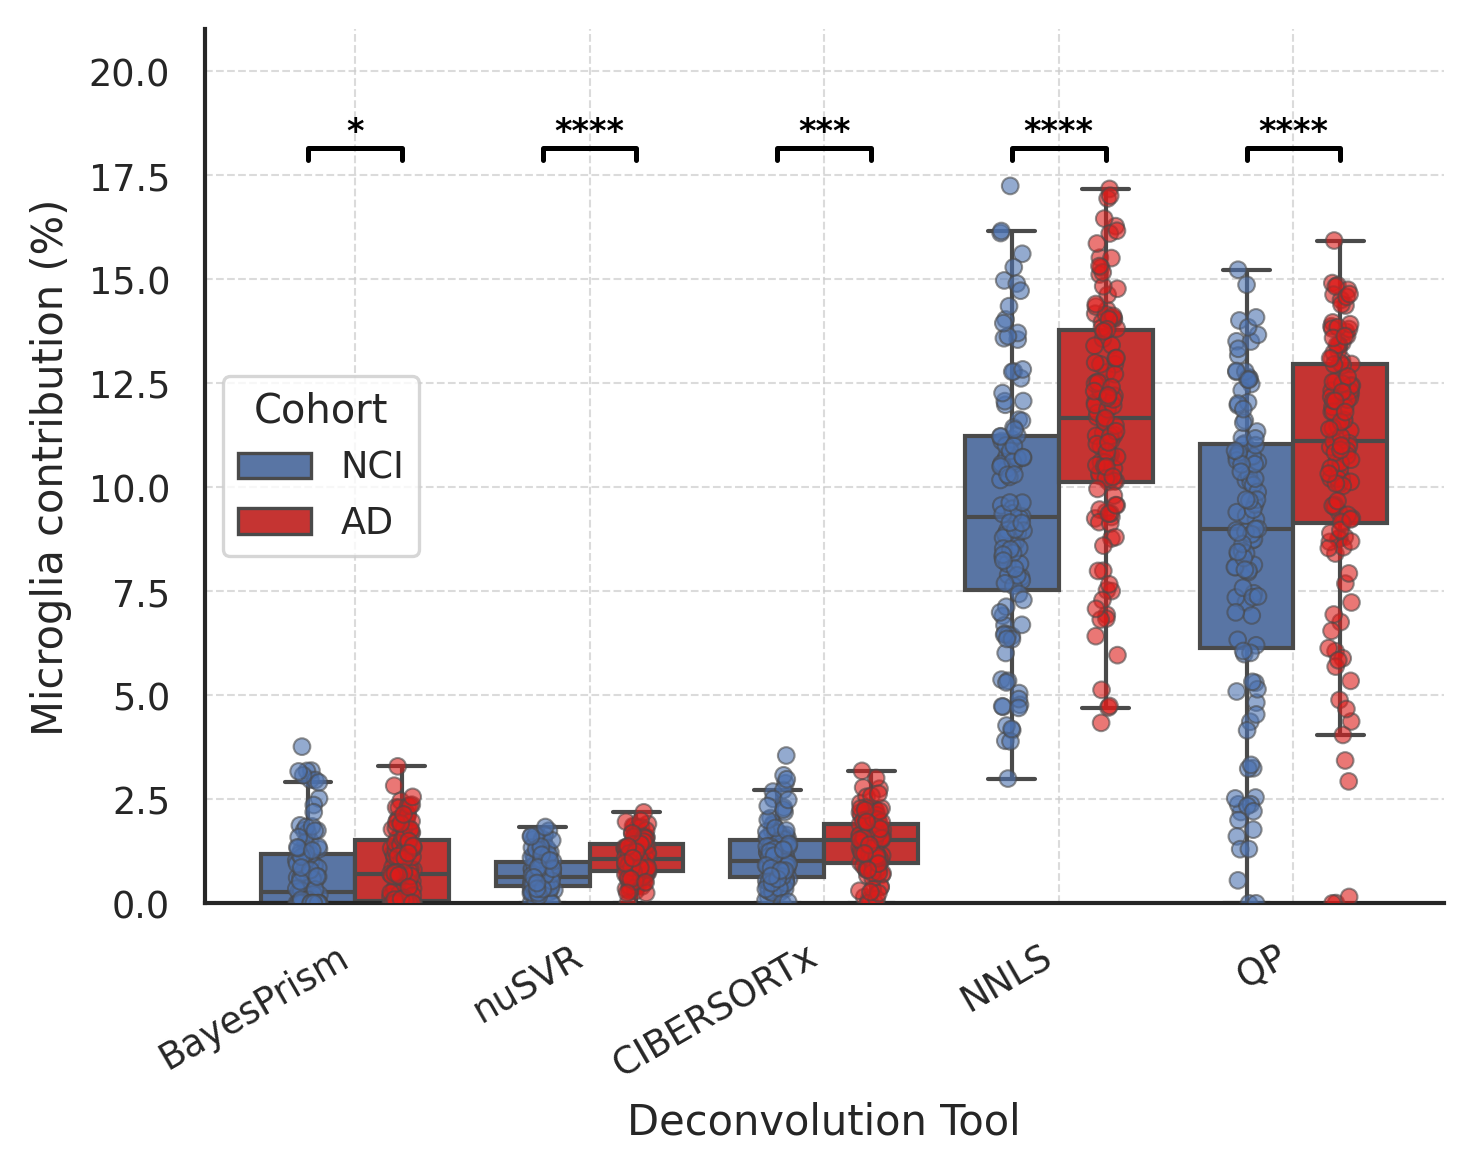

Saved: AD_vs_NCI_Microglia_boxstrip_BHWithinTool.svg


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

def add_bracket(ax, x1, x2, y, text, height):
    if text in ["", None] or pd.isna(text):
        return
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.2, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black")

# ---------- Settings ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
palette = {"NCI": "#4C72B0", "AD": "#DD1C1A"}
hue_offsets = {"NCI": -0.20, "AD": 0.20}


# merge labels: neuron + neurons
plot_label = {"neuron": "Neuron", "neurons": "Neuron", "microglia": "Microglia"}

targets = ["Neuron", "Microglia"]

# ---------- Create PlotCellType in BOTH long_df and results_df ----------
plot_long = long_df.copy()
plot_long["PlotCellType"] = plot_long["CellType"].map(plot_label).fillna(plot_long["CellType"])

plot_res = results_df.copy()
plot_res["PlotCellType"] = plot_res["CellType"].map(plot_label).fillna(plot_res["CellType"])

# Only draw brackets for BH-significant comparisons
plot_res["Stars_plot"] = plot_res["Stars_BH"].fillna("ns")

# Ensure ordering
plot_long["Method"] = pd.Categorical(plot_long["Method"], categories=tool_order, ordered=True)
plot_long["Cohort"] = pd.Categorical(plot_long["Cohort"], categories=["NCI", "AD"], ordered=True)

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

for ct in targets:
    df_ct = plot_long[plot_long["PlotCellType"].eq(ct)].copy()
    if df_ct.empty:
        print(f"Skipping {ct}: no data found.")
        continue
        # tools that actually exist for this cell type
    tools_present = (
        df_ct["Method"]
        .dropna()
        .unique()
        .tolist()
    )

    # keep original order, but drop missing ones (e.g. MuSiC for microglia)
    tools_present = [t for t in tool_order if t in tools_present]

    # enforce ordering on subset
    df_ct["Method"] = pd.Categorical(
        df_ct["Method"],
        categories=tools_present,
        ordered=True
    )    
    # stars per tool for this ct (BH-within-tool already done in results_df)
    stars_map = (
        plot_res.loc[plot_res["PlotCellType"].eq(ct), ["Method", "Stars_plot"]]
        .dropna(subset=["Method"])
        .set_index("Method")["Stars_plot"]
        .to_dict()
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.boxplot(
        data=df_ct, x="Method", y="Contribution", hue="Cohort",
        palette=palette, dodge=True, showfliers=False, ax=ax
    )
    sns.stripplot(
        data=df_ct, x="Method", y="Contribution", hue="Cohort",
        palette=palette, dodge=True, jitter=True, alpha=0.6,
        linewidth=0.5, size=4, ax=ax
    )

    # single legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Cohort", frameon=True)

    # ---------- Fixed y-limits per cell type ----------
    if ct == "Neuron":
        ax.set_ylim(0, 8)
    elif ct == "Microglia":
        ax.set_ylim(0, 21)

    # Bracket placement inside current axis
    y0, y1 = ax.get_ylim()
    yr = max(y1 - y0, 1e-6)
    base_y = y0 + 0.85 * yr
    height = 0.3

    # tool -> x
    xticks = ax.get_xticks()
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    tool_to_x = dict(zip(xticklabels, xticks))

    for tool in tool_order:
        star = stars_map.get(tool, "")
        if (not star) or (tool not in tool_to_x):
            continue
        x = tool_to_x[tool]
        add_bracket(ax, x + hue_offsets["NCI"], x + hue_offsets["AD"], base_y, star, height)

    ax.set_xlabel("Deconvolution Tool", fontsize=10)
    ax.set_ylabel(f"{ct} contribution (%)", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    sns.despine()
    plt.tight_layout()
    out = f"AD_vs_NCI_{ct}_boxstrip_BHWithinTool.svg"
    plt.savefig(out, format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {out}")
